# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.train import train_model
from src.eval import plot_samples_grid

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

Device:                  cuda
Figure rows will be: 	 method
Figure columns will be:  k

Running sampling with method = ULA and k = 4.0
Swaps within [1. 4.]

time 90: x has standard deviation 1.02

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.9926049709320068

time 80: x has standard deviation 1.18

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.9983325004577637

time 70: x has standard deviation 1.40

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.9985706210136414

time 60: x has standard deviation 1.64

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.998799741268158

time 50: x has standard deviation 1.87

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.9985776543617249

time 40: x has standard deviation 2.08

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.9983217120170593

time 30: x has standard deviation 2.25

Langevin step 0
From chain k=4.0 and k=1.0 acceptance 0.998167097568512

time 20: x has standard deviation 2.38

Langevi

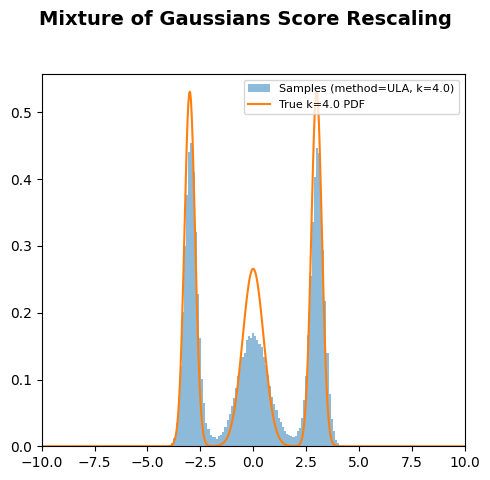

In [ ]:
dataset_name = "composed"
methods = ["ULA"]
k = [4.0]
sigma = 0.5
step_scale = 0.5
n_langevin_steps = 1
filename = "testing_parallel"

samples, figures = plot_samples_grid(
	dataset_name=dataset_name, 
	method=methods, 
	k=k, 
	sigma=sigma, 
	step_scale=step_scale, 
	n_langevin_steps=n_langevin_steps, 
	x_limit = 10, save_dir="figures", filename=filename
)

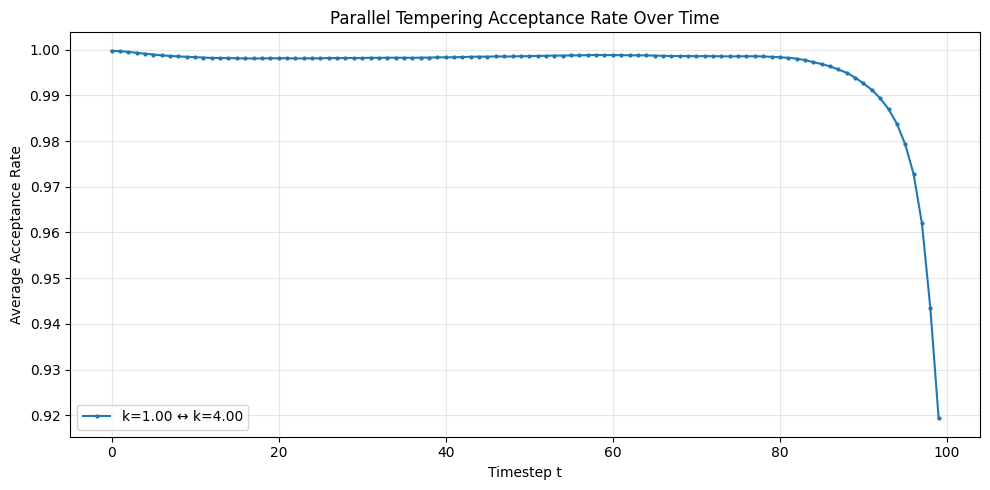

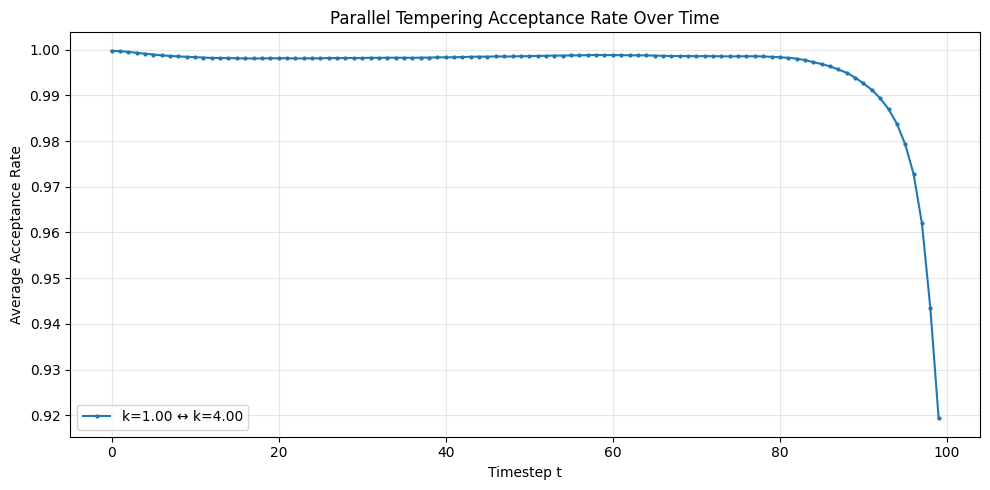

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

def plot_acceptance_over_time(acceptance_ladder):

	fig, ax = plt.subplots(figsize=(10, 5))

	for (k_less, k_more), records in acceptance_ladder.items():
		# Group acceptance rates by timestep t
		by_time = defaultdict(list)
		for r in records:
			by_time[r["t"]].append(r["acceptance"].cpu().mean().item())

		# Average over langevin steps at each t
		ts = sorted(by_time.keys())
		ts_cpu = [item.cpu() for item in ts]

		avg_acceptance = [sum(by_time[t]) / len(by_time[t]) for t in ts]

		ax.plot(ts_cpu, avg_acceptance, label=f"k={k_less:.2f} ↔ k={k_more:.2f}", marker='o', markersize=2)

	ax.set_xlabel("Timestep t")
	ax.set_ylabel("Average Acceptance Rate")
	ax.set_title("Parallel Tempering Acceptance Rate Over Time")
	ax.legend()
	ax.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

	return fig

plot_acceptance_over_time(figures)

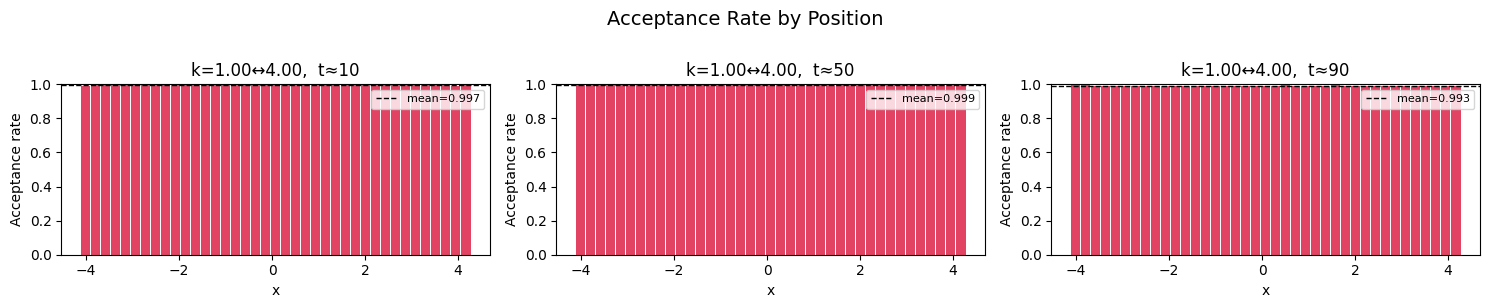

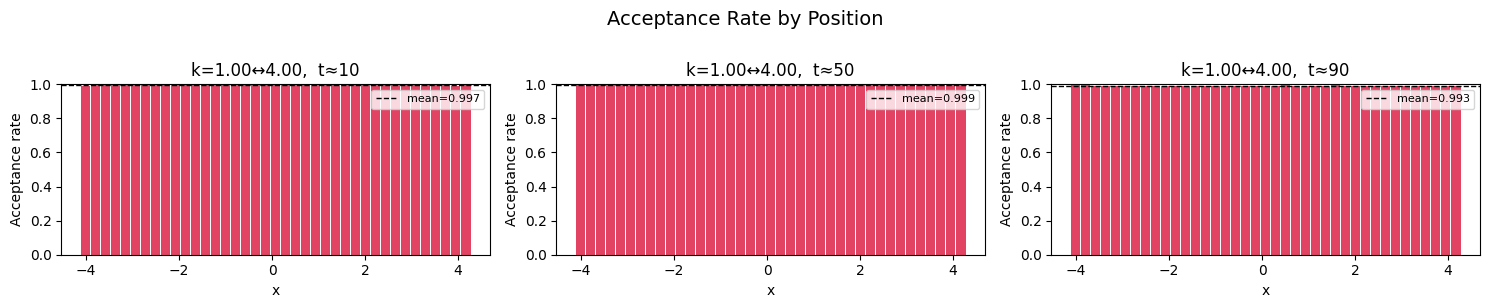

In [20]:
import numpy as np
import torch

def plot_acceptance_over_position(acceptance_ladder, x_final, timesteps_to_show=[10, 50, 90]):
    x_np = x_final.detach().cpu().numpy().flatten()
    
    bins = np.linspace(x_np.min(), x_np.max(), 40)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    n_pairs = len(acceptance_ladder)
    n_times = len(timesteps_to_show)
    
    fig, axes = plt.subplots(
        n_pairs, n_times,
        figsize=(5 * n_times, 3 * n_pairs),
        sharex=True
    )
    if n_pairs == 1:
        axes = axes[np.newaxis, :]
    if n_times == 1:
        axes = axes[:, np.newaxis]

    for row, ((k_less, k_more), records) in enumerate(acceptance_ladder.items()):
        by_time = defaultdict(list)
        for r in records:
            by_time[r["t"]].append(r["acceptance"].cpu())

        for col, t in enumerate(timesteps_to_show):
            ax = axes[row, col]

            closest_t = min(by_time.keys(), key=lambda t_: abs(t_ - t))
            stacked = torch.stack(by_time[closest_t], dim=0).float()  # (n_langevin, n_particles)
            per_particle_acceptance = stacked.mean(dim=0).numpy().flatten()

            bin_indices = np.digitize(x_np, bins) - 1
            bin_indices = np.clip(bin_indices, 0, len(bin_centers) - 1)

            bin_acceptance = np.full(len(bin_centers), np.nan)
            for b in range(len(bin_centers)):
                mask = bin_indices == b
                if mask.sum() > 0:
                    bin_acceptance[b] = per_particle_acceptance[mask].mean()

            valid = ~np.isnan(bin_acceptance)
            ax.bar(bin_centers[valid], bin_acceptance[valid],
                   width=bin_width * 0.9, color="crimson", alpha=0.8)
            
            mean_acc = np.nanmean(bin_acceptance)
            ax.axhline(mean_acc, color='black', linestyle='--', linewidth=1,
                       label=f"mean={mean_acc:.3f}")
            
            ax.set_ylim(0, 1)
            ax.set_ylabel("Acceptance rate")
            ax.set_xlabel("x")
            ax.set_title(f"k={k_less:.2f}↔{k_more:.2f},  t≈{closest_t}")
            ax.legend(fontsize=8)

    fig.suptitle("Acceptance Rate by Position", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig
plot_acceptance_over_position(figures, samples[(0,0)]["samples"])